In [231]:
import pandas as pd
import re
import numpy as np


In [232]:
df = pd.read_csv("C:/Users/User/AILabEngineers/task3/data/raw/krisha1.csv")
df = df.iloc[3:]

In [233]:
df.head()

,price,text,area,flat_toilets,balcony,current_floors,total_floors,ceiling,dorm,mortgage,year,type_of_house,condition,repair_status,type_of_floor,location
3,17900000.0,"1-комнатная квартира · 45 м² · 3/9 этаж, Кайым...",45 м²,раздельный,балкон и лоджия,3.0,9.0,NaN,NaN,NaN,2020.0,NaN,NaN,полностью,ламинат,"Астана, Нура р-н\nпоказать на карте"
4,17600000.0,"1-комнатная квартира · 39 м² · 5/7 этаж, Болек...",39 м²,совмещенный,лоджия,5.0,7.0,2.8,NaN,NaN,2019.0,кирпичный,NaN,полностью,ламинат,"Астана, Алматы р-н\nпоказать на карте"
5,29900000.0,"2-комнатная квартира · 48.76 м² · 2/9 этаж, Жо...",48.76 м²,NaN,NaN,2.0,9.0,3.0,нет,NaN,2025.0,монолитный,черновая отделка,NaN,NaN,Астана\nпоказать на карте
6,27000000.0,"3-комнатная квартира · 85 м² · 8/12 этаж, Майл...",85 м²,раздельный,NaN,8.0,12.0,3.0,нет,NaN,2024.0,монолитный,NaN,NaN,NaN,"Астана, Алматы р-н\nпоказать на карте"
7,105000000.0,"4-комнатная квартира · 128.5 м² · 3/6 этаж, Ще...",128.5 м²,NaN,NaN,3.0,6.0,3.0,нет,NaN,2025.0,монолитный,NaN,NaN,NaN,"Алматы, Ауэзовский р-н\nпоказать на карте"


In [234]:
df['price'].describe().apply(lambda x: f"{x:,.0f}")

count            5,341
mean        39,411,923
std         39,450,610
min          3,000,000
25%         20,200,000
50%         29,800,000
75%         45,000,000
max      1,196,000,000
Name: price, dtype: object

In [235]:
print(f"Duplicates: {df.duplicated().sum()}")
df = df.drop_duplicates()


Duplicates: 904


In [236]:
print("Nan values by columns:")
print(df.isnull().sum())

Nan values by columns:
price             1095
text                 1
area                 2
flat_toilets      2057
balcony           4923
current_floors    1217
total_floors      1217
ceiling           2017
dorm              1688
mortgage          5461
year                 2
type_of_house      337
condition         3220
repair_status     2577
type_of_floor     2757
location             2
dtype: int64


In [237]:
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values")

text: 5726 unique values
area: 1746 unique values
flat_toilets: 4 unique values
balcony: 4 unique values
dorm: 2 unique values
mortgage: 1 unique values
type_of_house: 4 unique values
condition: 5 unique values
repair_status: 3 unique values
type_of_floor: 7 unique values
location: 220 unique values


In [238]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5738 entries, 3 to 6644
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   price           4643 non-null   float64
 1   text            5737 non-null   object 
 2   area            5736 non-null   object 
 3   flat_toilets    3681 non-null   object 
 4   balcony         815 non-null    object 
 5   current_floors  4521 non-null   float64
 6   total_floors    4521 non-null   float64
 7   ceiling         3721 non-null   float64
 8   dorm            4050 non-null   object 
 9   mortgage        277 non-null    object 
 10  year            5736 non-null   float64
 11  type_of_house   5401 non-null   object 
 12  condition       2518 non-null   object 
 13  repair_status   3161 non-null   object 
 14  type_of_floor   2981 non-null   object 
 15  location        5736 non-null   object 
dtypes: float64(5), object(11)
memory usage: 762.1+ KB


In [239]:
df["area"]

3          45 м²
4          39 м²
5       48.76 м²
6          85 м²
7       128.5 м²
          ...   
6640     32.9 м²
6641       50 м²
6642       70 м²
6643     34.9 м²
6644       50 м²
Name: area, Length: 5738, dtype: object

In [240]:
def clean_area_column(df):
    def extract_total_area(text):
        match = re.search(r'[\d.]+', str(text))
        return float(match.group()) if match else None

    df['area'] = df['area'].apply(extract_total_area)
    return df 


In [241]:
df = clean_area_column(df)
print(df['area'].dtype)


float64


In [242]:
df["area"].describe()

count    5736.000000
mean       71.719383
std        37.801111
min         8.400000
25%        46.300000
50%        63.100000
75%        85.000000
max       400.000000
Name: area, dtype: float64

In [243]:
df.isnull().sum()

price             1095
text                 1
area                 2
flat_toilets      2057
balcony           4923
current_floors    1217
total_floors      1217
ceiling           2017
dorm              1688
mortgage          5461
year                 2
type_of_house      337
condition         3220
repair_status     2577
type_of_floor     2757
location             2
dtype: int64

In [244]:
df['text'][:1]

3    1-комнатная квартира · 45 м² · 3/9 этаж, Кайым...
Name: text, dtype: object

In [245]:
df[df['text'].isnull()]

,price,text,area,flat_toilets,balcony,current_floors,total_floors,ceiling,dorm,mortgage,year,type_of_house,condition,repair_status,type_of_floor,location
820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [246]:
df = df.dropna(subset=['price', 'area', 'text']).reset_index(drop=True)


In [247]:
df.isnull().sum()

price                0
text                 0
area                 0
flat_toilets      2034
balcony           3828
current_floors     122
total_floors       122
ceiling            927
dorm               593
mortgage          4366
year                 0
type_of_house      335
condition         2125
repair_status     1482
type_of_floor     1662
location             0
dtype: int64

In [248]:
df['balcony'].unique()

array(['балкон и лоджия', 'лоджия', nan, 'балкон',
       'несколько балконов или лоджий'], dtype=object)

In [249]:
df['mortgage'].unique()


array([nan, 'В залоге'], dtype=object)

In [250]:
df['mortgage'] = df['mortgage'].fillna('нет')
df['dorm'] = df['dorm'].fillna('нет')

In [251]:
df.isnull().sum()

price                0
text                 0
area                 0
flat_toilets      2034
balcony           3828
current_floors     122
total_floors       122
ceiling            927
dorm                 0
mortgage             0
year                 0
type_of_house      335
condition         2125
repair_status     1482
type_of_floor     1662
location             0
dtype: int64

In [252]:
df['flat_toilets'].value_counts()

flat_toilets
совмещенный      1151
раздельный       1086
2 с/у и более     369
нет                 3
Name: count, dtype: int64

In [253]:
df['repair_status'].value_counts()

repair_status
полностью     1848
частично      1028
без мебели     285
Name: count, dtype: int64

In [254]:
df['year'].value_counts()

year
2024.0    427
2023.0    312
2022.0    258
2025.0    244
2020.0    237
         ... 
1952.0      1
1949.0      1
1948.0      1
1957.0      1
1947.0      1
Name: count, Length: 79, dtype: int64

In [255]:
df[df['year'] == 2025]

,price,text,area,flat_toilets,balcony,current_floors,total_floors,ceiling,dorm,mortgage,year,type_of_house,condition,repair_status,type_of_floor,location
2,29900000.0,"2-комнатная квартира · 48.76 м² · 2/9 этаж, Жо...",48.76,NaN,NaN,2.0,9.0,3.00,нет,нет,2025.0,монолитный,черновая отделка,NaN,NaN,Астана\nпоказать на карте
4,105000000.0,"4-комнатная квартира · 128.5 м² · 3/6 этаж, Ще...",128.50,NaN,NaN,3.0,6.0,3.00,нет,нет,2025.0,монолитный,NaN,NaN,NaN,"Алматы, Ауэзовский р-н\nпоказать на карте"
5,30000000.0,"1-комнатная квартира · 47.99 м² · 3/9 этаж, Ма...",47.99,раздельный,NaN,3.0,9.0,3.00,нет,нет,2025.0,монолитный,NaN,NaN,NaN,"Астана, Есильский р-н\nпоказать на карте"
7,39000000.0,"2-комнатная квартира · 50 м² · 3/3 этаж, Егора...",50.00,NaN,NaN,3.0,3.0,3.00,нет,нет,2025.0,монолитный,черновая отделка,NaN,NaN,"Алматы, Наурызбайский р-н\nпоказать на карте"
10,24000000.0,"2-комнатная квартира · 52.6 м² · 8/9 этаж, мкр...",52.60,NaN,NaN,8.0,9.0,2.70,нет,нет,2025.0,монолитный,черновая отделка,NaN,NaN,"Алматы, Алатауский р-н\nпоказать на карте"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4592,23000000.0,"1-комнатная квартира · 34.6 м² · 3/3 этаж, Жан...",34.60,NaN,NaN,3.0,3.0,3.00,нет,нет,2025.0,монолитный,NaN,NaN,NaN,"Каскелен, Алматинская обл.\nпоказать на карте"
4605,24000000.0,"1-комнатная квартира · 35 м² · 15/17 этаж, Хус...",35.00,совмещенный,NaN,15.0,17.0,2.70,нет,нет,2025.0,монолитный,NaN,полностью,ламинат,"Астана, Есильский р-н\nпоказать на карте"
4612,14130300.0,"1-комнатная квартира · 38.19 м² · 6/9 этаж, На...",38.19,совмещенный,балкон,6.0,9.0,3.00,нет,нет,2025.0,кирпичный,NaN,NaN,NaN,"Кокшетау, Акмолинская обл.\nпоказать на карте"
4629,14864500.0,"1-комнатная квартира · 47.72 м² · 4/9 этаж, Ке...",47.72,NaN,несколько балконов или лоджий,4.0,9.0,2.75,нет,нет,2025.0,кирпичный,NaN,NaN,NaN,"Кокшетау, Акмолинская обл.\nпоказать на карте"


In [256]:
df['condition'].value_counts()

condition
свежий ремонт                     1368
не новый, но аккуратный ремонт     730
черновая отделка                   240
требует ремонта                    123
свободная планировка                57
Name: count, dtype: int64

In [257]:
df[df['condition'] == "черновая отделка"]

,price,text,area,flat_toilets,balcony,current_floors,total_floors,ceiling,dorm,mortgage,year,type_of_house,condition,repair_status,type_of_floor,location
2,29900000.0,"2-комнатная квартира · 48.76 м² · 2/9 этаж, Жо...",48.76,NaN,NaN,2.0,9.0,3.00,нет,нет,2025.0,монолитный,черновая отделка,NaN,NaN,Астана\nпоказать на карте
7,39000000.0,"2-комнатная квартира · 50 м² · 3/3 этаж, Егора...",50.00,NaN,NaN,3.0,3.0,3.00,нет,нет,2025.0,монолитный,черновая отделка,NaN,NaN,"Алматы, Наурызбайский р-н\nпоказать на карте"
10,24000000.0,"2-комнатная квартира · 52.6 м² · 8/9 этаж, мкр...",52.60,NaN,NaN,8.0,9.0,2.70,нет,нет,2025.0,монолитный,черновая отделка,NaN,NaN,"Алматы, Алатауский р-н\nпоказать на карте"
12,18000000.0,"1-комнатная квартира · 42.1 м² · 20/23 этаж, А...",42.10,NaN,NaN,20.0,23.0,2.85,нет,нет,2024.0,монолитный,черновая отделка,без мебели,NaN,"Астана, Алматы р-н\nпоказать на карте"
51,114000000.0,"5-комнатная квартира · 244.5 м² · 9/10 этаж, п...",244.50,NaN,NaN,9.0,10.0,3.00,нет,нет,2021.0,монолитный,черновая отделка,NaN,NaN,"Астана, Есильский р-н\nпоказать на карте"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4575,32400000.0,"3-комнатная квартира · 81 м² · 2/14 этаж, Селе...",81.00,NaN,NaN,2.0,14.0,3.00,нет,нет,2026.0,монолитный,черновая отделка,NaN,NaN,"Семей, Абай обл.\nпоказать на карте"
4579,34190000.0,"4-комнатная квартира · 131.5 м² · 5/6 этаж, мк...",131.50,совмещенный,NaN,5.0,6.0,3.00,нет,В залоге,2018.0,кирпичный,черновая отделка,NaN,NaN,"Актобе, мкр. Алтын орда\nпоказать на карте"
4591,103540500.0,"3-комнатная квартира · 132.3 м² · 6/7 этаж, Мк...",132.30,NaN,NaN,6.0,7.0,NaN,нет,нет,2008.0,монолитный,черновая отделка,NaN,NaN,"Алматы, Бостандыкский р-н\nпоказать на карте"
4610,78500000.0,"3-комнатная квартира · 118 м² · 3/16 этаж, Ман...",118.00,NaN,NaN,3.0,16.0,3.00,нет,нет,2024.0,монолитный,черновая отделка,NaN,NaN,"Астана, Есильский р-н\nпоказать на карте"


In [258]:
df['type_of_floor']

0        ламинат
1        ламинат
2            NaN
3            NaN
4            NaN
          ...   
4638    линолеум
4639         NaN
4640         NaN
4641     ламинат
4642     ламинат
Name: type_of_floor, Length: 4643, dtype: object

In [259]:
df['text']

0       1-комнатная квартира · 45 м² · 3/9 этаж, Кайым...
1       1-комнатная квартира · 39 м² · 5/7 этаж, Болек...
2       2-комнатная квартира · 48.76 м² · 2/9 этаж, Жо...
3       3-комнатная квартира · 85 м² · 8/12 этаж, Майл...
4       4-комнатная квартира · 128.5 м² · 3/6 этаж, Ще...
                              ...                        
4638    1-комнатная квартира · 32.9 м² · 4/4 этаж, мкр...
4639    2-комнатная квартира · 50 м² · 8/12 этаж, мкр ...
4640    3-комнатная квартира · 70 м² · 2/5 этаж, мкр Н...
4641    1-комнатная квартира · 34.9 м² · 4/5 этаж, Мик...
4642    3-комнатная квартира · 50 м² · 2/5 этаж, Новат...
Name: text, Length: 4643, dtype: object

In [260]:
def extract_rooms(text):
    """Извлекает количество комнат (1, 2, 3...) из строки"""
    match = re.search(r'(\d+)-комнатная', str(text))
    return int(match.group(1)) if match else None

def extract_street(text):
    """Извлекает название улицы после последней запятой"""
    if pd.isna(text):
        return None
    parts = str(text).split(',')
    return parts[-1].strip() if len(parts) > 1 else None

# Применяем к датафрейму
df['rooms'] = df['text'].apply(extract_rooms)
df['street'] = df['text'].apply(extract_street)

# Удаляем исходный столбец
df.drop(columns='text', inplace=True)

In [261]:
df

,price,area,flat_toilets,balcony,current_floors,total_floors,ceiling,dorm,mortgage,year,type_of_house,condition,repair_status,type_of_floor,location,rooms,street
0,17900000.0,45.00,раздельный,балкон и лоджия,3.0,9.0,NaN,нет,нет,2020.0,NaN,NaN,полностью,ламинат,"Астана, Нура р-н\nпоказать на карте",1,Кайым Мухаметханова 28
1,17600000.0,39.00,совмещенный,лоджия,5.0,7.0,2.8,нет,нет,2019.0,кирпичный,NaN,полностью,ламинат,"Астана, Алматы р-н\nпоказать на карте",1,Болекпаева 8
2,29900000.0,48.76,NaN,NaN,2.0,9.0,3.0,нет,нет,2025.0,монолитный,черновая отделка,NaN,NaN,Астана\nпоказать на карте,2,Жошы Хан 20
3,27000000.0,85.00,раздельный,NaN,8.0,12.0,3.0,нет,нет,2024.0,монолитный,NaN,NaN,NaN,"Астана, Алматы р-н\nпоказать на карте",3,Майлина 6
4,105000000.0,128.50,NaN,NaN,3.0,6.0,3.0,нет,нет,2025.0,монолитный,NaN,NaN,NaN,"Алматы, Ауэзовский р-н\nпоказать на карте",4,Щепкина 42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4638,13500000.0,32.90,совмещенный,NaN,4.0,4.0,NaN,нет,нет,2010.0,NaN,свежий ремонт,NaN,линолеум,"Атырау, мкр Нурсая\nпоказать на карте",1,№29садик жаге частный садиктер толып тұр
4639,29000000.0,50.00,NaN,NaN,8.0,12.0,NaN,нет,нет,2024.0,NaN,NaN,NaN,NaN,"Шымкент, Абайский р-н\nпоказать на карте",2,мкр Шымсити 50B
4640,30000000.0,70.00,NaN,NaN,2.0,5.0,NaN,нет,нет,1972.0,NaN,NaN,NaN,NaN,"Караганда, Казыбек би р-н\nпоказать на карте",3,Абдирова 53 — Абдирова
4641,24500000.0,34.90,NaN,NaN,4.0,5.0,2.8,нет,нет,2023.0,монолитный,свежий ремонт,полностью,ламинат,"Алматы, Алатауский р-н\nпоказать на карте",1,142/67 к4 2


In [262]:
def clean_location(text):
    """Удаляет '\nпоказать на карте' и делит на город + район"""
    if pd.isna(text):
        return pd.Series([None, None])
    
    # Удаляем \n и всё после него
    cleaned = str(text).split('\n')[0]
    
    # Делим по запятой
    parts = cleaned.split(',')

    city = parts[0].strip() if len(parts) > 0 else None
    district = parts[1].strip() if len(parts) > 1 else None

    return pd.Series([city, district])

df[['city', 'district']] = df['location'].apply(clean_location)

# Чистим лишнее: \n, "показать на карте", лишние пробелы (вдруг остались)
df['city'] = df['city'].str.replace(r'показать.*', '', regex=True).str.strip()
df['district'] = df['district'].str.replace(r'показать.*', '', regex=True).str.strip()

# Удаляем колонку location
df.drop(columns='location', inplace=True)


In [263]:
df

,price,area,flat_toilets,balcony,current_floors,total_floors,ceiling,dorm,mortgage,year,type_of_house,condition,repair_status,type_of_floor,rooms,street,city,district
0,17900000.0,45.00,раздельный,балкон и лоджия,3.0,9.0,NaN,нет,нет,2020.0,NaN,NaN,полностью,ламинат,1,Кайым Мухаметханова 28,Астана,Нура р-н
1,17600000.0,39.00,совмещенный,лоджия,5.0,7.0,2.8,нет,нет,2019.0,кирпичный,NaN,полностью,ламинат,1,Болекпаева 8,Астана,Алматы р-н
2,29900000.0,48.76,NaN,NaN,2.0,9.0,3.0,нет,нет,2025.0,монолитный,черновая отделка,NaN,NaN,2,Жошы Хан 20,Астана,None
3,27000000.0,85.00,раздельный,NaN,8.0,12.0,3.0,нет,нет,2024.0,монолитный,NaN,NaN,NaN,3,Майлина 6,Астана,Алматы р-н
4,105000000.0,128.50,NaN,NaN,3.0,6.0,3.0,нет,нет,2025.0,монолитный,NaN,NaN,NaN,4,Щепкина 42,Алматы,Ауэзовский р-н
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4638,13500000.0,32.90,совмещенный,NaN,4.0,4.0,NaN,нет,нет,2010.0,NaN,свежий ремонт,NaN,линолеум,1,№29садик жаге частный садиктер толып тұр,Атырау,мкр Нурсая
4639,29000000.0,50.00,NaN,NaN,8.0,12.0,NaN,нет,нет,2024.0,NaN,NaN,NaN,NaN,2,мкр Шымсити 50B,Шымкент,Абайский р-н
4640,30000000.0,70.00,NaN,NaN,2.0,5.0,NaN,нет,нет,1972.0,NaN,NaN,NaN,NaN,3,Абдирова 53 — Абдирова,Караганда,Казыбек би р-н
4641,24500000.0,34.90,NaN,NaN,4.0,5.0,2.8,нет,нет,2023.0,монолитный,свежий ремонт,полностью,ламинат,1,142/67 к4 2,Алматы,Алатауский р-н


In [264]:
df['district'] = df['district'].str.replace(r'р-н|мкр|пос.|район', '', regex=True).str.strip()
df


,price,area,flat_toilets,balcony,current_floors,total_floors,ceiling,dorm,mortgage,year,type_of_house,condition,repair_status,type_of_floor,rooms,street,city,district
0,17900000.0,45.00,раздельный,балкон и лоджия,3.0,9.0,NaN,нет,нет,2020.0,NaN,NaN,полностью,ламинат,1,Кайым Мухаметханова 28,Астана,Нура
1,17600000.0,39.00,совмещенный,лоджия,5.0,7.0,2.8,нет,нет,2019.0,кирпичный,NaN,полностью,ламинат,1,Болекпаева 8,Астана,Алматы
2,29900000.0,48.76,NaN,NaN,2.0,9.0,3.0,нет,нет,2025.0,монолитный,черновая отделка,NaN,NaN,2,Жошы Хан 20,Астана,None
3,27000000.0,85.00,раздельный,NaN,8.0,12.0,3.0,нет,нет,2024.0,монолитный,NaN,NaN,NaN,3,Майлина 6,Астана,Алматы
4,105000000.0,128.50,NaN,NaN,3.0,6.0,3.0,нет,нет,2025.0,монолитный,NaN,NaN,NaN,4,Щепкина 42,Алматы,Ауэзовский
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4638,13500000.0,32.90,совмещенный,NaN,4.0,4.0,NaN,нет,нет,2010.0,NaN,свежий ремонт,NaN,линолеум,1,№29садик жаге частный садиктер толып тұр,Атырау,Нурсая
4639,29000000.0,50.00,NaN,NaN,8.0,12.0,NaN,нет,нет,2024.0,NaN,NaN,NaN,NaN,2,мкр Шымсити 50B,Шымкент,Абайский
4640,30000000.0,70.00,NaN,NaN,2.0,5.0,NaN,нет,нет,1972.0,NaN,NaN,NaN,NaN,3,Абдирова 53 — Абдирова,Караганда,Казыбек би
4641,24500000.0,34.90,NaN,NaN,4.0,5.0,2.8,нет,нет,2023.0,монолитный,свежий ремонт,полностью,ламинат,1,142/67 к4 2,Алматы,Алатауский


In [265]:
df['city'].value_counts()

city
Алматы        1325
Астана        1287
Шымкент        211
Караганда      187
Актобе         178
              ... 
КазЦИК           1
Топар            1
Красный яр       1
Шахтинск         1
Заречное         1
Name: count, Length: 87, dtype: int64

In [266]:
df['district'].value_counts()   

district
Есильский        467
Бостандыкский    349
Алматы           323
Ауэзовский       207
Нура             195
                ... 
Сазда-4            1
"Шыгыс 1"          1
27-й               1
5-й                1
Коктем             1
Name: count, Length: 142, dtype: int64

In [267]:
df.isnull().sum()   

price                0
area                 0
flat_toilets      2034
balcony           3828
current_floors     122
total_floors       122
ceiling            927
dorm                 0
mortgage             0
year                 0
type_of_house      335
condition         2125
repair_status     1482
type_of_floor     1662
rooms                0
street               0
city                 0
district            81
dtype: int64

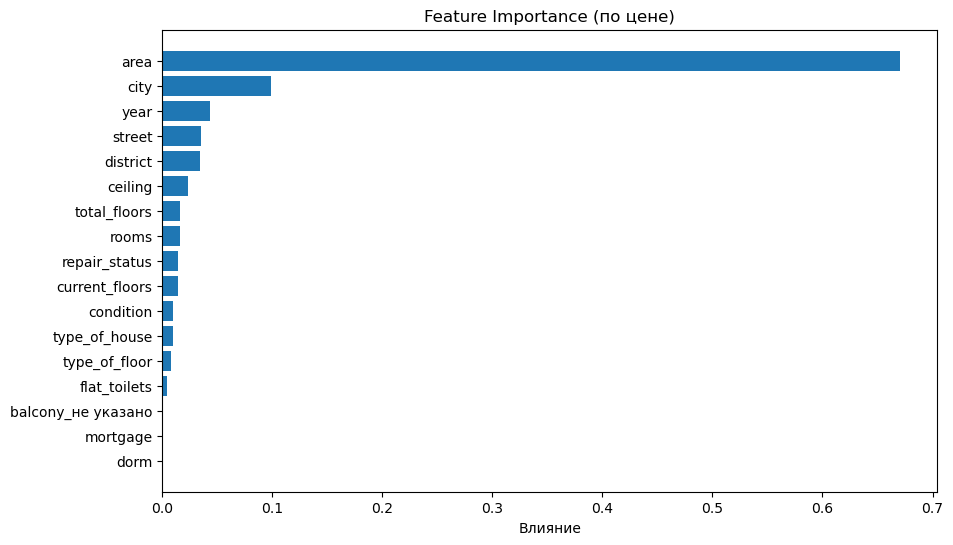

,feature,importance
0,area,0.670753
14,city,0.098522
7,year,0.043630
13,street,0.035464
15,district,0.034010
4,ceiling,0.023635
3,total_floors,0.015988
12,rooms,0.015817
10,repair_status,0.014651
2,current_floors,0.014173


In [290]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# 1. Удалим строки, где отсутствует цена
df_model = df.dropna(subset=['price']).copy()

# 2. Временно заполним NaN
df_model = df_model.fillna('unknown')

# 3. Преобразуем все категориальные фичи в строки
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = df_model[col].astype(str)
    df_model[col] = LabelEncoder().fit_transform(df_model[col])

# 4. Подготовим данные
X = df_model.drop(columns=['price'])
y = df_model['price']

# 5. Обучим модель
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# 6. Importance
importances = model.feature_importances_
features = X.columns

# 7. Сортировка и вывод
importance_df = pd.DataFrame({'feature': features, 'importance': importances})
importance_df = importance_df.sort_values(by='importance', ascending=False)

# Вывод
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance (по цене)")
plt.xlabel("Влияние")
plt.show()

# Также таблицей
importance_df


In [269]:
df.isnull().sum()

price                0
area                 0
flat_toilets      2034
balcony           3828
current_floors     122
total_floors       122
ceiling            927
dorm                 0
mortgage             0
year                 0
type_of_house      335
condition         2125
repair_status     1482
type_of_floor     1662
rooms                0
street               0
city                 0
district            81
dtype: int64

In [270]:
df[['area', 'rooms']].corr()


,area,rooms
area,1.000000,0.777079
rooms,0.777079,1.000000


In [292]:
df['balcony_не указано'].replace({True: 1, False: 0}, inplace=True)

In [294]:
df[['balcony_не указано', 'price']].corr()

,balcony_не указано,price
balcony_не указано,1.000000,0.111838
price,0.111838,1.000000


<Axes: xlabel='balcony_не указано', ylabel='price'>

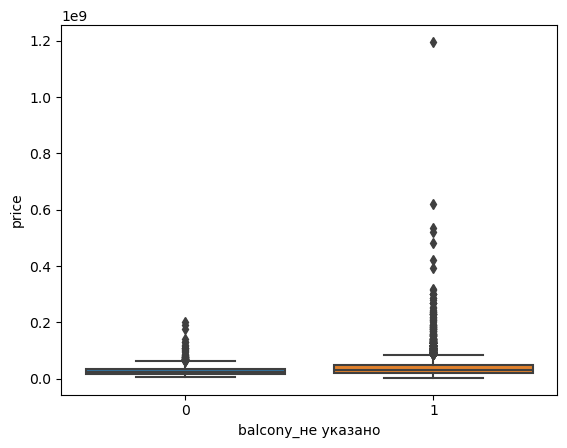

In [295]:
import seaborn as sns
sns.boxplot(x='balcony_не указано', y='price', data=df) 

In [272]:
df.isnull().sum()

price                0
area                 0
flat_toilets      2034
balcony           3828
current_floors     122
total_floors       122
ceiling            927
dorm                 0
mortgage             0
year                 0
type_of_house      335
condition         2125
repair_status     1482
type_of_floor     1662
rooms                0
street               0
city                 0
district            81
dtype: int64

In [273]:
df['district'].unique()

array(['Нура', 'Алматы', None, 'Ауэзовский', 'Есильский', 'Наурызбайский',
       'Сарыарка', 'Алатауский', 'Сарайшык', 'Турксибский', 'Алмалинский',
       'Акмолинская обл.', 'Бостандыкский', 'Каратауский', '13-й', '31Б',
       'Жамбылская обл.', 'Жетысуский', 'Медеуский', 'Павлодарская обл.',
       'Байконур', 'Алматинская обл.', 'Казыбек би',
       'Западно-Казахстанская обл.', 'Восточно-Казахстанская обл.',
       'Сары Арка', '. Алтын орда', '28-й', 'Улытау обл.', '17-й',
       'Жана Орда', 'жилой массив Жилянка', 'Костанайская обл.',
       'Абайский', 'Жетысу обл.', 'Аль-Фарабийский', 'Мангистауская обл.',
       'Туркестанская обл.', 'Карагандинская обл.', 'Кадыра Мырза-Али',
       'Жилгородок', '11-й', '20а', 'Енбекшинский', '35-', 'Ульбинский',
       'Атырауская обл.', 'Абай обл.', 'Кызылординская обл.', 'Туран',
       'Алихана Бокейханова', 'Кунаева', 'Нурсая', '12',
       '. Зачаганск пгт', 'Северо-Восток', 'Нур Актобе', '32А', '31-й',
       '11', 'Актюбинская обл

In [274]:
def clean_balcony(value):
    if pd.isna(value):
        return 'не указано'
    return 'есть'

In [275]:
df["balcony"] = df["balcony"].apply(clean_balcony)

In [276]:
df.isnull().sum()

price                0
area                 0
flat_toilets      2034
balcony              0
current_floors     122
total_floors       122
ceiling            927
dorm                 0
mortgage             0
year                 0
type_of_house      335
condition         2125
repair_status     1482
type_of_floor     1662
rooms                0
street               0
city                 0
district            81
dtype: int64

In [278]:
from sklearn.inspection import permutation_importance

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)

result = permutation_importance(model, X_val, y_val, n_repeats=10, random_state=42)

perm_df = pd.DataFrame({
    'feature': X.columns,
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

perm_df.head(15)


,feature,importance
0,area,1.593993
15,city,0.276738
13,rooms,0.120378
8,year,0.045156
16,district,0.028659
5,ceiling,0.015127
14,street,0.007853
3,current_floors,0.002723
9,type_of_house,0.002520
12,type_of_floor,0.002457


In [279]:
df['mortgage'].unique()

array(['нет', 'В залоге'], dtype=object)

In [280]:
df.groupby('mortgage')['price'].mean()

mortgage
В залоге    3.634618e+07
нет         3.949400e+07
Name: price, dtype: float64

In [281]:
df['dorm'].unique()

array(['нет', 'да'], dtype=object)

In [282]:
df.groupby('dorm')['price'].count()

dorm
да       53
нет    4590
Name: price, dtype: int64

In [283]:
df[df['dorm'] == 'да']

,price,area,flat_toilets,current_floors,total_floors,ceiling,dorm,mortgage,year,type_of_house,condition,repair_status,type_of_floor,rooms,street,city,district,balcony_не указано
229,10200000.0,12.5,раздельный,4.0,5.0,2.70,да,нет,1979.0,кирпичный,NaN,частично,линолеум,1,мкр Орбита-3 52 — КазГАСА,Алматы,Бостандыкский,True
405,9000000.0,18.4,NaN,2.0,5.0,2.70,да,нет,1984.0,панельный,свежий ремонт,полностью,линолеум,1,Сатпаева,Астана,Алматы,True
504,21500000.0,48.1,2 с/у и более,3.0,3.0,NaN,да,нет,1981.0,кирпичный,требует ремонта,частично,линолеум,2,Сейфуллина — Айбасова,Алматы,Турксибский,True
547,5500000.0,18.0,раздельный,2.0,5.0,NaN,да,нет,1987.0,NaN,NaN,NaN,линолеум,1,мкр Северо-Восток 15/2 — Север восток,Уральск,Северо-Восток,False
608,13940000.0,16.0,раздельный,2.0,5.0,2.70,да,нет,1975.0,кирпичный,NaN,полностью,NaN,1,ул Утеген батыр 73 — Ул Жубанова,Алматы,Ауэзовский,True
653,41000000.0,59.5,раздельный,9.0,9.0,2.80,да,нет,1982.0,панельный,свежий ремонт,NaN,ламинат,2,Толе би 177 — Ауэзова,Алматы,Алмалинский,True
675,14700000.0,21.0,NaN,2.0,3.0,2.80,да,нет,1979.0,кирпичный,NaN,полностью,ламинат,1,майлина 117 — Майлина 117 Писарева,Алматы,Турксибский,False
700,32800000.0,55.0,раздельный,2.0,5.0,NaN,да,нет,1985.0,NaN,NaN,частично,ламинат,2,Байзакова — Жамбыла,Алматы,Алмалинский,False
897,8000000.0,18.9,нет,2.0,2.0,NaN,да,нет,1965.0,NaN,NaN,NaN,NaN,1,Чернышевского 2 — Акан Серы,Алматы,Турксибский,True
938,3500000.0,17.4,совмещенный,4.0,5.0,2.80,да,нет,1983.0,панельный,требует ремонта,NaN,линолеум,1,Терешковой 18 . Номер 2 общежитие 4 подъезд 4 ...,Шымкент,Аль-Фарабийский,True


In [284]:
df.groupby("city")['price'].mean().sort_values(ascending=False).head(10)

city
Алматы              5.828959e+07
Астана              4.007314e+07
Талгарский р-н      3.950000e+07
Атырау              3.566610e+07
Шымкент             3.314427e+07
Отеген батыр        3.152857e+07
Караганда           3.128639e+07
Кокшетау            3.028995e+07
Акмолинская обл.    3.000000e+07
Актобе              2.997549e+07
Name: price, dtype: float64

In [285]:
df.groupby("city")['price'].count().sort_values(ascending=False).head(15)

city
Алматы              1325
Астана              1287
Шымкент              211
Караганда            187
Актобе               178
Усть-Каменогорск     163
Актау                135
Атырау               131
Тараз                100
Уральск               99
Костанай              99
Павлодар              90
Кокшетау              65
Семей                 53
Кызылорда             50
Name: price, dtype: int64

In [286]:
df.isnull().sum()

price                    0
area                     0
flat_toilets          2034
current_floors         122
total_floors           122
ceiling                927
dorm                     0
mortgage                 0
year                     0
type_of_house          335
condition             2125
repair_status         1482
type_of_floor         1662
rooms                    0
street                   0
city                     0
district                81
balcony_не указано       0
dtype: int64

In [287]:
df['condition'].unique()
df.groupby("condition")['price'].mean().sort_values(ascending=False).head(10)

condition
свежий ремонт                     4.288993e+07
черновая отделка                  4.105266e+07
не новый, но аккуратный ремонт    3.521243e+07
свободная планировка              3.382215e+07
требует ремонта                   3.010566e+07
Name: price, dtype: float64

In [288]:
df.groupby("condition")['price'].count().sort_values(ascending=False).head(10)

condition
свежий ремонт                     1368
не новый, но аккуратный ремонт     730
черновая отделка                   240
требует ремонта                    123
свободная планировка                57
Name: price, dtype: int64

In [289]:
df['balcony'].unique()
df.groupby("balcony")['price'].mean().sort_values(ascending=False).head(10)

KeyError: 'balcony'

In [296]:
df

,price,area,flat_toilets,current_floors,total_floors,ceiling,dorm,mortgage,year,type_of_house,condition,repair_status,type_of_floor,rooms,street,city,district,balcony_не указано
0,17900000.0,45.00,раздельный,3.0,9.0,NaN,нет,нет,2020.0,NaN,NaN,полностью,ламинат,1,Кайым Мухаметханова 28,Астана,Нура,0
1,17600000.0,39.00,совмещенный,5.0,7.0,2.8,нет,нет,2019.0,кирпичный,NaN,полностью,ламинат,1,Болекпаева 8,Астана,Алматы,0
2,29900000.0,48.76,NaN,2.0,9.0,3.0,нет,нет,2025.0,монолитный,черновая отделка,NaN,NaN,2,Жошы Хан 20,Астана,None,1
3,27000000.0,85.00,раздельный,8.0,12.0,3.0,нет,нет,2024.0,монолитный,NaN,NaN,NaN,3,Майлина 6,Астана,Алматы,1
4,105000000.0,128.50,NaN,3.0,6.0,3.0,нет,нет,2025.0,монолитный,NaN,NaN,NaN,4,Щепкина 42,Алматы,Ауэзовский,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4638,13500000.0,32.90,совмещенный,4.0,4.0,NaN,нет,нет,2010.0,NaN,свежий ремонт,NaN,линолеум,1,№29садик жаге частный садиктер толып тұр,Атырау,Нурсая,1
4639,29000000.0,50.00,NaN,8.0,12.0,NaN,нет,нет,2024.0,NaN,NaN,NaN,NaN,2,мкр Шымсити 50B,Шымкент,Абайский,1
4640,30000000.0,70.00,NaN,2.0,5.0,NaN,нет,нет,1972.0,NaN,NaN,NaN,NaN,3,Абдирова 53 — Абдирова,Караганда,Казыбек би,1
4641,24500000.0,34.90,NaN,4.0,5.0,2.8,нет,нет,2023.0,монолитный,свежий ремонт,полностью,ламинат,1,142/67 к4 2,Алматы,Алатауский,1
